In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv('../../data/raw/credit_data.csv')

### Check data types
Incorrect data types could indicate errors in data.

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 594642 entries, 0 to 594641
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594642 non-null  int64  
 1   customer     594642 non-null  str    
 2   age          594642 non-null  str    
 3   gender       594642 non-null  str    
 4   zipcodeori   594642 non-null  str    
 5   merchant     594642 non-null  str    
 6   zipmerchant  594642 non-null  str    
 7   category     594642 non-null  str    
 8   amount       594642 non-null  float64
 9   fraud        594642 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 45.4 MB


In [43]:
df.describe()

,step,amount,fraud
count,594642.000000,594642.000000,594642.000000
mean,94.986987,37.890191,0.012108
std,51.053526,111.402916,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000


### Check for missing data
If there are missing values, fill or remove during data preparation. 

In [44]:
df.isna().sum()

step           0
customer       0
age            0
gender         0
zipcodeori     0
merchant       0
zipmerchant    0
category       0
amount         0
fraud          0
dtype: int64

### Check for duplicates
If there are duplicates, remove or manage during data preparation.

In [45]:
df.duplicated().any()

np.False_

In [46]:
df[df.duplicated()]

,step,customer,age,gender,zipcodeori,merchant,zipmerchant,category,amount,fraud


### Separate Values 
Create a separate list of values of whether things are categorical, continual numeric, or binary numeric

In [47]:
cat_cols, cont_cols, binary_cols = [], [], []

for col in df.columns:
    if df[col].dtype == "str":
        cat_cols.append(col)
    else:
        if df[col].nunique() > 2:
            cont_cols.append(col)
        elif col != "fraud":
            binary_cols.append(col)


print("Categorical Columns:", cat_cols)

print("Continous Columns:", cont_cols)
print("Binary Columns:", binary_cols)

Categorical Columns: ['customer', 'age', 'gender', 'zipcodeori', 'merchant', 'zipmerchant', 'category']
Continous Columns: ['step', 'amount']
Binary Columns: []


### Inspect Unique Values in the Dataset


In [48]:
cols_to_drop = []
for col in cat_cols:
   unum = df[col].nunique()

   print(f"Unique numbers of {col}s:", unum)

   if unum == 1:
      cols_to_drop.append(col)

print("\nDropping columns due to constant values:", cols_to_drop)

for col in cols_to_drop:
   cat_cols.remove(col)

df.drop(columns=cols_to_drop, inplace=True)


Unique numbers of customers: 4112
Unique numbers of ages: 8
Unique numbers of genders: 4
Unique numbers of zipcodeoris: 1
Unique numbers of merchants: 50
Unique numbers of zipmerchants: 1
Unique numbers of categorys: 15

Dropping columns due to constant values: ['zipcodeori', 'zipmerchant']


### Get Customer Data
Find the local values of data per customer

Customer transaction frequencies:
 customer
'C1978250683'    265
'C1275518867'    252
'C806399525'     237
'C515668508'     205
'C1338396147'    195
                ... 
'C1156745710'      6
'C1345586046'      6
'C1743702978'      5
'C1404665203'      5
'C1809646275'      5
Name: count, Length: 4112, dtype: int64


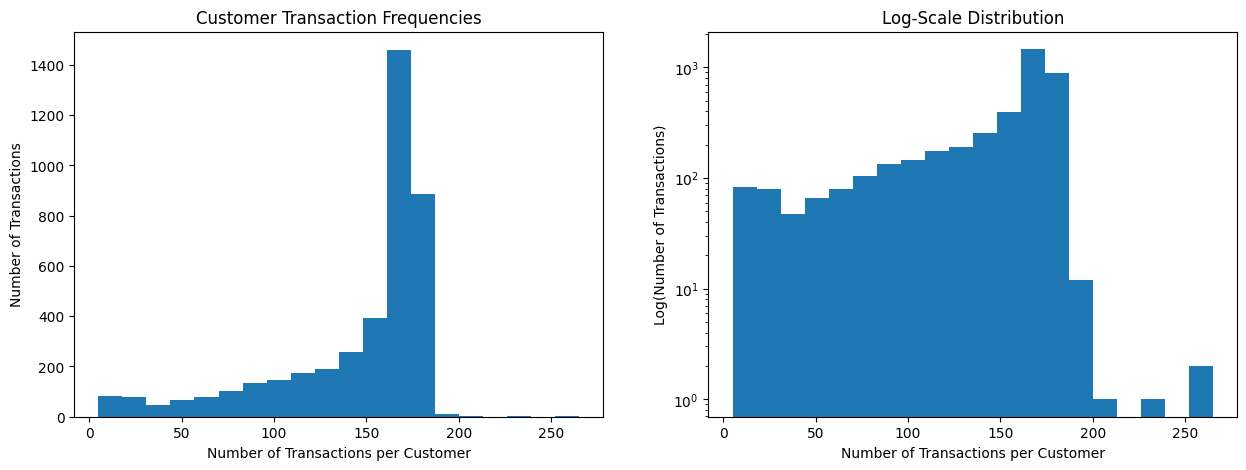

In [49]:
cust_freq = df["customer"].value_counts()
print("Customer transaction frequencies:\n", cust_freq)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(cust_freq, bins=20)
axes[0].set_title("Customer Transaction Frequencies")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xlabel("Number of Transactions per Customer")

axes[1].hist(cust_freq, bins=20, log=True)
axes[1].set_title("Log-Scale Distribution")
axes[1].set_ylabel("Log(Number of Transactions)")
axes[1].set_xlabel("Number of Transactions per Customer")

plt.show()